# Feature Engineering - Purchase prediction (RFM + temporal features)
- Synthetic transaction table
- Compute per-user features: recency, frequency, monetary, purchases_last_7, purchases_last_30, active_flag, avg_interpurchase_days
- Small label: purchased in next 30 days (for quick sanity-check / feature importance)

Requirements: pandas, numpy, matplotlib, xgboost, sklearn

In [14]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import xgboost as xgb

In [15]:
# Data

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def simulate_transactions(n_users=2000, start='2023-01-01', days=540):
    """
    Simulate a transactional log:
      user_id, date, purchase_amount
    Users have heterogeneous frequency and amounts.
    """
    start = pd.to_datetime(start)
    dates = pd.date_range(start, periods=days, freq='D')
    rows = []
    for user in range(n_users):
        # user-specific purchase rate and avg amount
        base_rate = np.clip(np.random.beta(0.8, 8) * 0.2, 0.01, 0.8)
        avg_amount = np.random.lognormal(mean=3.5, sigma=0.6)
        for d in dates:
            if np.random.rand() < base_rate:  # purchase happens
                qty = 1
                amt = np.round(np.random.normal(avg_amount, avg_amount * 0.2), 2)
                amt = float(max(1.0, amt))
                rows.append((user, d, amt))
    df = pd.DataFrame(rows, columns=['user_id', 'date', 'purchase_amount'])
    df = df.sort_values(['user_id', 'date']).reset_index(drop=True)
    return df

In [16]:

# Generate synthetic data
tx = simulate_transactions(n_users=2000, start='2023-01-01', days=540)

# Cutoff for feature calculation (end of observation window)
cutoff = tx['date'].max() - pd.Timedelta(days=30)  # label window = next 30 days
label_window_end = cutoff + pd.Timedelta(days=30)

# Create label: whether user purchased in next 30 days after cutoff
future_tx = tx[(tx['date'] > cutoff) & (tx['date'] <= label_window_end)]
label = future_tx.groupby('user_id').size().rename('purchased_next_30').reset_index()
label['purchased_next_30'] = (label['purchased_next_30'] > 0).astype(int)

# Feature calculation window: use transactions up to cutoff
hist = tx[tx['date'] <= cutoff].copy()

# Base RFM features
agg = hist.groupby('user_id').agg(
    frequency=('date', 'count'),
    last_purchase=('date', 'max'),
    monetary_mean=('purchase_amount', 'mean'),
    first_purchase=('date', 'min')
).reset_index()

agg['recency_days'] = (cutoff - agg['last_purchase']).dt.days
agg['tenure_days'] = (cutoff - agg['first_purchase']).dt.days
agg['avg_order_value'] = agg['monetary_mean']

# Purchases in last 7 and 30 days
hist['days_from_cutoff'] = (cutoff - hist['date']).dt.days
p7 = hist[hist['days_from_cutoff'] <= 7].groupby('user_id').size().rename('purchases_last_7')
p30 = hist[hist['days_from_cutoff'] <= 30].groupby('user_id').size().rename('purchases_last_30')

agg = agg.merge(p7.reset_index(), on='user_id', how='left').merge(p30.reset_index(), on='user_id', how='left')
agg[['purchases_last_7','purchases_last_30']] = agg[['purchases_last_7','purchases_last_30']].fillna(0).astype(int)

# Active flag: any purchase in last 30 days
agg['active_30d'] = (agg['purchases_last_30'] > 0).astype(int)

# Average inter-purchase days (per user)
def avg_interpurchase_days(group):
    dates = group['date'].sort_values()
    if len(dates) < 2:
        return np.nan
    diffs = dates.diff().dt.days.dropna()
    return diffs.mean()

ipd = hist.groupby('user_id').apply(avg_interpurchase_days).rename('avg_interpurchase_days').reset_index()
agg = agg.merge(ipd, on='user_id', how='left')

# Fill NA for users with single purchase by using tenure as proxy
agg['avg_interpurchase_days'] = agg['avg_interpurchase_days'].fillna(agg['tenure_days'].replace(0, np.nan)).fillna(agg['recency_days']+1)

# Merge label
data = agg.merge(label[['user_id','purchased_next_30']], on='user_id', how='left')
data['purchased_next_30'] = data['purchased_next_30'].fillna(0).astype(int)

Feature head:


,recency_days,frequency,avg_order_value,purchases_last_7,purchases_last_30,active_30d,tenure_days,avg_interpurchase_days
0,310,4,86.92,0,0,0,442,44.00
1,10,14,66.42,0,1,1,500,37.69
2,121,7,23.03,0,0,0,462,56.83
3,74,13,35.17,0,0,0,487,34.42
4,21,21,68.87,0,1,1,462,22.05



Label balance:
                       prop
purchased_next_30          
0                  0.578368
1                  0.421632


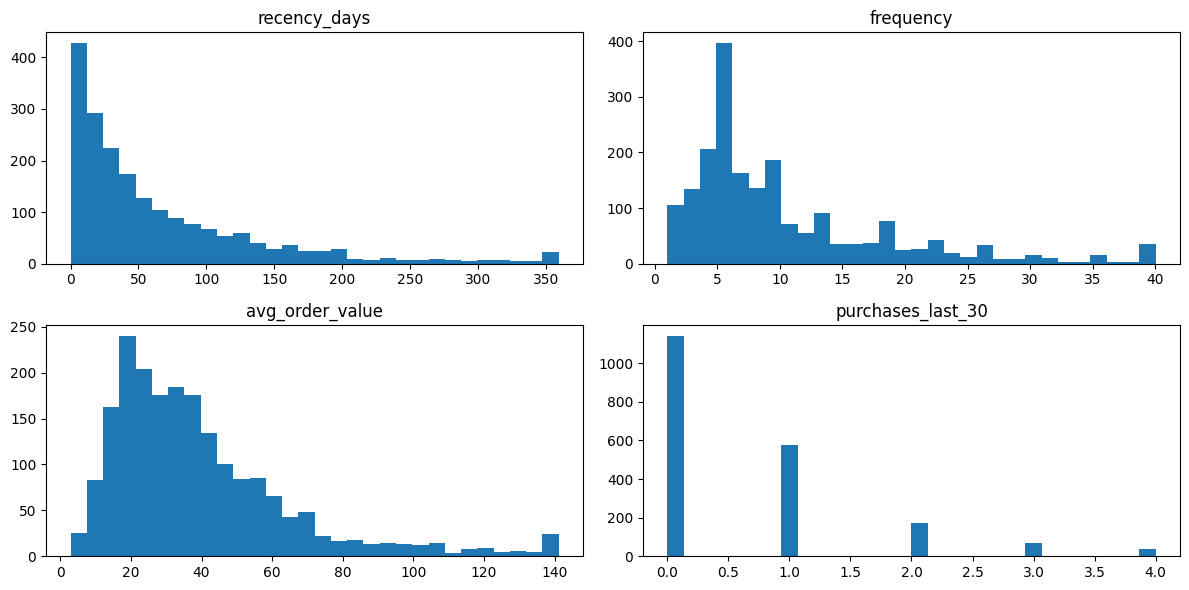


Quick predictive check (AUC): 0.600


In [20]:
# Feature selection and simple transforms
features = [
    'recency_days', 'frequency', 'avg_order_value',
    'purchases_last_7', 'purchases_last_30', 'active_30d',
    'tenure_days', 'avg_interpurchase_days'
]
X = data[features].copy()
y = data['purchased_next_30']

# Quick sanity check: display head and distributions
print('Feature head:')
display(X.head().round(2))
print('\nLabel balance:')
print(y.value_counts(normalize=True).rename('prop').to_frame())

# Plot a few distributions
plt.figure(figsize=(12,6))
for i, col in enumerate(['recency_days','frequency','avg_order_value','purchases_last_30']):
    plt.subplot(2,2,i+1)
    plt.hist(X[col].clip(0, X[col].quantile(0.99)), bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

# Quick predictive check (not the focus: only to show feature usefulness)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y)
model = xgb.XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_SEED)
model.fit(X_train, y_train)
pred_proba = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, pred_proba)
print(f'\nQuick predictive check (AUC): {auc:.3f}')

In [21]:
# Train (cleaned params) — replace previous XGBClassifier call
model = xgb.XGBClassifier(n_estimators=200, eval_metric='logloss', random_state=RANDOM_SEED)
model.fit(X_train, y_train)

# Predict & AUC
pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, pred_proba)
print(f'\nQuick predictive check (AUC): {auc:.3f}')

# Robust feature importance extraction
imp_dict = model.get_booster().get_score(importance_type='gain')  # returns dict like {'f0': 12.3, 'f1': 0.3} or {'recency_days': ...}

# Determine feature names in the order used by the model
if hasattr(model, 'feature_names_in_'):
    feature_names = list(model.feature_names_in_)
else:
    feature_names = features  # fallback to your original feature list

# Map importance for each feature (support both named keys and f{index} keys)
importance_values = []
for idx, fname in enumerate(feature_names):
    # try named key, then f{idx}, then 0.0
    importance_values.append(
        imp_dict.get(fname, imp_dict.get(f"f{idx}", 0.0))
    )

imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importance_values
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('\nFeature importances (gain):')
display(imp)

# Final dataset sample to export / use in pipelines
final = data[['user_id'] + features + ['purchased_next_30']]
print('\nFinal feature table sample:')
display(final.head())

# Save example (optional)
# final.to_csv('user_features_rfm.csv', index=False)


Quick predictive check (AUC): 0.600

Feature importances (gain):


,feature,importance
0,frequency,1.788197
1,tenure_days,0.698508
2,recency_days,0.698046
3,avg_order_value,0.687092
4,avg_interpurchase_days,0.610911
5,purchases_last_30,0.605760
6,purchases_last_7,0.264069
7,active_30d,0.000000



Final feature table sample:


,user_id,recency_days,frequency,avg_order_value,purchases_last_7,purchases_last_30,active_30d,tenure_days,avg_interpurchase_days,purchased_next_30
0,0,310,4,86.915000,0,0,0,442,44.000000,0
1,1,10,14,66.420714,0,1,1,500,37.692308,0
2,2,121,7,23.032857,0,0,0,462,56.833333,0
3,3,74,13,35.174615,0,0,0,487,34.416667,1
4,4,21,21,68.872381,0,1,1,462,22.050000,0


SHAP summary (feature importance - mean absolute SHAP):


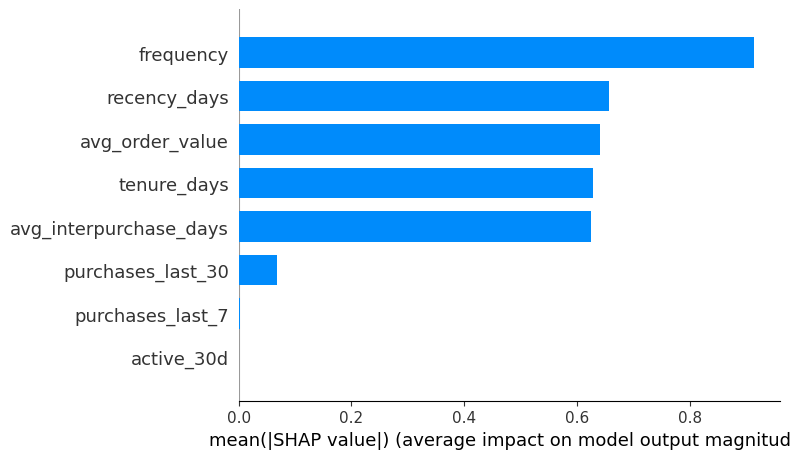


SHAP summary (beeswarm):


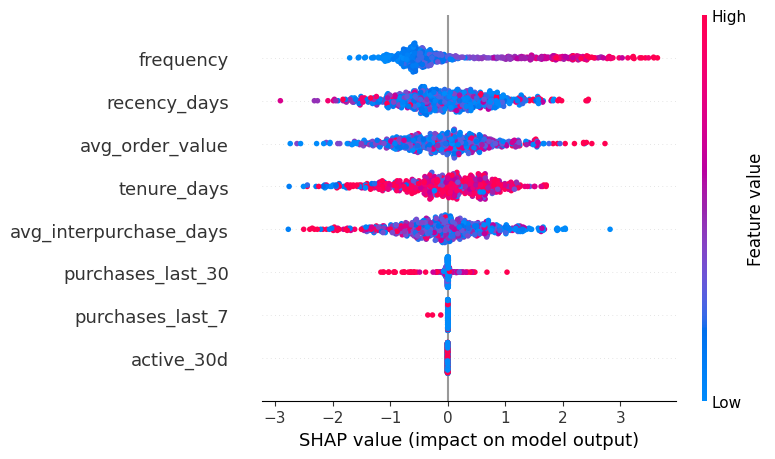


Top feature by mean(|SHAP|): frequency


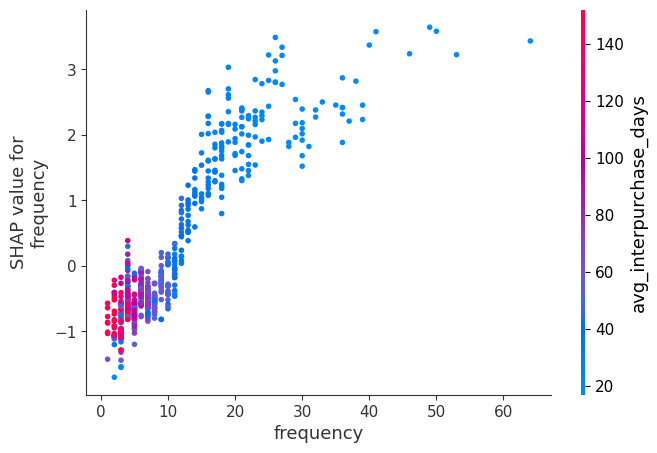


Example local explanations (first 3 rows):
Row 0:
  recency_days: SHAP=+0.9497
  tenure_days: SHAP=-0.4154
  avg_interpurchase_days: SHAP=+0.3110
  frequency: SHAP=+0.1292
  avg_order_value: SHAP=+0.0766
  purchases_last_30: SHAP=+0.0027

Row 1:
  avg_order_value: SHAP=+1.5508
  recency_days: SHAP=+1.2371
  tenure_days: SHAP=+0.6896
  frequency: SHAP=-0.6414
  avg_interpurchase_days: SHAP=+0.2248
  purchases_last_30: SHAP=+0.0049

Row 2:
  tenure_days: SHAP=-0.4074
  avg_interpurchase_days: SHAP=-0.1156
  frequency: SHAP=+0.1135
  recency_days: SHAP=+0.0199
  avg_order_value: SHAP=-0.0195
  purchases_last_30: SHAP=-0.0085



In [19]:
# SHAP explanation for the XGBoost model
# Place this after you have trained `model` and have `X_train`, `X_test`, `features` defined.
# Requirements: shap (pip install shap). This snippet is robust to different SHAP versions.

import warnings
warnings.filterwarnings("ignore")

try:
    import shap
except Exception as e:
    raise ImportError("Please install shap (pip install shap) to run SHAP explanations.") from e

# Use a small background sample for speed (k samples from train)
background = X_train.sample(n=min(200, len(X_train)), random_state=RANDOM_SEED)

# Create explainer (TreeExplainer works well for XGBoost)
explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent" if hasattr(shap, "TreeExplainer") else None)

# Compute SHAP values for test set (or a subset for speed)
X_for_shap = X_test.copy().reset_index(drop=True)
max_shap_samples = 1000
if len(X_for_shap) > max_shap_samples:
    X_for_shap = X_for_shap.sample(n=max_shap_samples, random_state=RANDOM_SEED).reset_index(drop=True)

# Newer shap versions return an Explanation object; handle both cases
shap_values = explainer.shap_values(X_for_shap) if hasattr(explainer, "shap_values") else explainer(X_for_shap)

# If shap_values is an Explanation object, extract values and base_values
if hasattr(shap_values, "values"):
    shap_vals_arr = shap_values.values
    base_values = shap_values.base_values if hasattr(shap_values, "base_values") else None
else:
    shap_vals_arr = shap_values
    base_values = None

# Plot summary (bar and beeswarm)
print("SHAP summary (feature importance - mean absolute SHAP):")
shap.summary_plot(shap_vals_arr, X_for_shap, feature_names=features, plot_type="bar", show=True)

print("\nSHAP summary (beeswarm):")
shap.summary_plot(shap_vals_arr, X_for_shap, feature_names=features, show=True)

# Identify top feature from mean(|SHAP|)
import numpy as np
mean_abs_shap = np.abs(shap_vals_arr).mean(axis=0)
top_idx = int(np.argmax(mean_abs_shap))
top_feature = features[top_idx]
print(f"\nTop feature by mean(|SHAP|): {top_feature}")

# Dependence plot for the top feature
# If shap API supports dependence_plot with arrays/DFs, use it. Otherwise fallback to manual scatter.
try:
    shap.dependence_plot(top_feature, shap_vals_arr, X_for_shap, feature_names=features, show=True)
except Exception:
    # Manual dependence-style plot: SHAP value for feature vs feature value
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,4))
    plt.scatter(X_for_shap[top_feature], shap_vals_arr[:, top_idx], alpha=0.6)
    plt.xlabel(top_feature)
    plt.ylabel("SHAP value")
    plt.title(f"Dependence: {top_feature}")
    plt.tight_layout()
    plt.show()

# Force clearing the JS visualizations if using notebook JS-based plots
try:
    shap.plots._force_matplotlib=True
except Exception:
    pass

# Optional: show per-row explanation for first 3 rows
print("\nExample local explanations (first 3 rows):")
for i in range(min(3, len(X_for_shap))):
    print(f"Row {i}:")
    try:
        shap.plots.waterfall(explainer(X_for_shap.iloc[[i]]), max_display=8, show=True)
    except Exception:
        # Fallback textual summary
        row_shap = shap_vals_arr[i]
        idx_sorted = np.argsort(-np.abs(row_shap))[:6]
        for idx in idx_sorted:
            print(f"  {features[idx]}: SHAP={row_shap[idx]:+.4f}")
    print()

SHAP confirms that frequency is by far the most influential predictor of future purchase, which aligns with behavioral theory: customers with stronger historical engagement are more likely to purchase again.

Recency, average order value, tenure, and purchase rhythm also contribute meaningfully, suggesting that both lifecycle stage and purchasing cadence matter.

Interestingly, binary activity flags such as purchases_last_7 and active_30d provide little incremental signal once continuous behavioral features are included. This suggests feature redundancy and highlights the importance of avoiding overly correlated feature engineering.